<a href="https://colab.research.google.com/github/parthadeori/amazon-product-pricing-and-customer-behavior-analysis/blob/main/Amazon_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Amazon Product Pricing & Customer Behavior Analysis**

### **Download Amazon Sales Dataset using KaggleHub**

In [52]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("karkavelrajaj/amazon-sales-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-sales-dataset' dataset.
Path to dataset files: /kaggle/input/amazon-sales-dataset


In [53]:
# Check the file
import os

path = "/kaggle/input/amazon-sales-dataset"
print(os.listdir(path))

['amazon.csv']


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = "/kaggle/input/amazon-sales-dataset"
df = pd.read_csv(f"{path}/amazon.csv")

df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [55]:
# Understand the Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

### **Data Cleaning (convert numeric columns)**

In [56]:
# Remove symbols and convert to numeric
df["discounted_price"] = df["discounted_price"].str.replace("₹", "").str.replace(",", "").astype(float)
df["actual_price"] = df["actual_price"].str.replace("₹", "").str.replace(",", "").astype(float)
df["discount_percentage"] = df["discount_percentage"].str.replace("%", "").astype(float)
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["rating_count"] = df["rating_count"].str.replace(",", "")
df["rating_count"] = pd.to_numeric(df["rating_count"], errors="coerce")

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   float64
 6   rating               1464 non-null   float64
 7   rating_count         1463 non-null   float64
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

In [58]:
df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1465.000000,1465.000000,1465.000000,1464.000000,1463.000000
mean,3125.310874,5444.990635,47.691468,4.096585,18295.541353
std,6944.304394,10874.826864,21.635905,0.291674,42753.864952
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,325.000000,800.000000,32.000000,4.000000,1186.000000
50%,799.000000,1650.000000,50.000000,4.100000,5179.000000
75%,1999.000000,4295.000000,63.000000,4.300000,17336.500000
max,77990.000000,139900.000000,94.000000,5.000000,426973.000000


In [59]:
df["rating"].describe()

,rating
count,1464.000000
mean,4.096585
std,0.291674
min,2.000000
25%,4.000000
50%,4.100000
75%,4.300000
max,5.000000


In [60]:
# Calculate discount value
df["discount_value"] = df["actual_price"] - df["discounted_price"]

# Compare key columns
df[["actual_price", "discounted_price", "discount_percentage", "discount_value"]].head(10)

,actual_price,discounted_price,discount_percentage,discount_value
0,1099.0,399.00,64.0,700.00
1,349.0,199.00,43.0,150.00
2,1899.0,199.00,90.0,1700.00
3,699.0,329.00,53.0,370.00
4,399.0,154.00,61.0,245.00
5,1000.0,149.00,85.0,851.00
6,499.0,176.63,65.0,322.37
7,299.0,229.00,23.0,70.00
8,999.0,499.00,50.0,500.00
9,299.0,199.00,33.0,100.00


### **Relationship between Price and Discount**

In [61]:
df[["actual_price", "discount_percentage"]].corr()

,actual_price,discount_percentage
actual_price,1.000000,-0.118098
discount_percentage,-0.118098,1.000000


In [62]:
df[["actual_price", "rating"]].corr()

,actual_price,rating
actual_price,1.000000,0.121642
rating,0.121642,1.000000


### **Category-level insights**

In [63]:
df.groupby("category").agg({
    "actual_price": "mean",
    "discount_percentage": "mean",
    "rating": "mean",
    "rating_count": "mean"
}).sort_values(by="actual_price", ascending=False)

,actual_price,discount_percentage,rating,rating_count
category,,,,
"Home&Kitchen|Heating,Cooling&AirQuality|AirConditioners|Split-SystemAirConditioners",75990.00000,43.000000,4.300000,3231.000000
Computers&Accessories|Laptops|TraditionalLaptops,59890.00000,38.000000,4.000000,323.000000
"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cleaning&Ironing|Vacuums&FloorCare|Vacuums|RoboticVacuums",44949.50000,45.000000,4.250000,3917.000000
"Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions",40132.84127,38.285714,4.209524,12067.920635
Computers&Accessories|Tablets,37999.00000,29.000000,4.600000,2886.000000
...,...,...,...,...
"OfficeProducts|OfficePaperProducts|Paper|Stationery|Notebooks,WritingPads&Diaries|WireboundNotebooks",150.00000,5.750000,4.400000,7130.250000
"OfficeProducts|OfficePaperProducts|Paper|Stationery|Pens,Pencils&WritingSupplies|Pens&Refills|BottledInk",100.00000,5.000000,4.300000,3078.000000
Home&Kitchen|CraftMaterials|DrawingMaterials|DrawingMedia|Pens,100.00000,10.000000,4.400000,10718.000000


In [64]:
df["main_category"] = df["category"].str.split("|").str[0]

df.groupby("main_category").agg({
    "actual_price": "mean",
    "discount_percentage": "mean",
    "rating": "mean",
    "rating_count": "mean"
}).sort_values(by="actual_price", ascending=False)

,actual_price,discount_percentage,rating,rating_count
main_category,,,,
Electronics,10127.311787,50.828897,4.081749,29997.809886
Home&Kitchen,4162.073661,40.120536,4.040716,6676.493304
Car&Motorbike,4000.000000,42.000000,3.800000,1118.000000
Health&PersonalCare,1900.000000,53.000000,4.000000,3663.000000
Computers&Accessories,1683.623135,54.024283,4.154967,17136.782705
MusicalInstruments,1347.000000,46.000000,3.900000,44441.000000
HomeImprovement,799.000000,57.500000,4.250000,4283.000000
OfficeProducts,397.193548,12.354839,4.309677,4828.225806
Toys&Games,150.000000,0.000000,4.300000,15867.000000


### **Price Distribution**

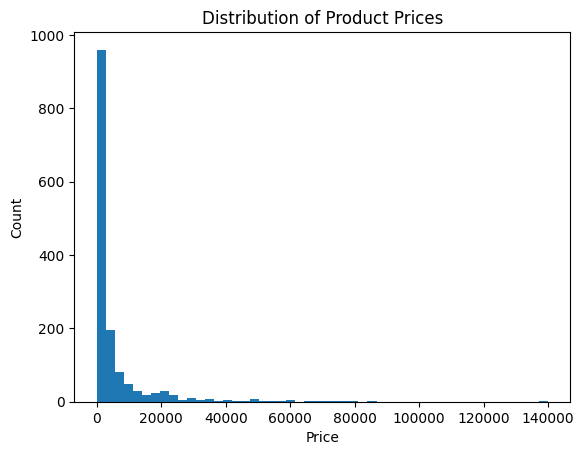

In [65]:
plt.hist(df["actual_price"], bins=50)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

Insight:

* Most products are low-mid range
* Few extreme expensive outliers

### **Discount Distribution**



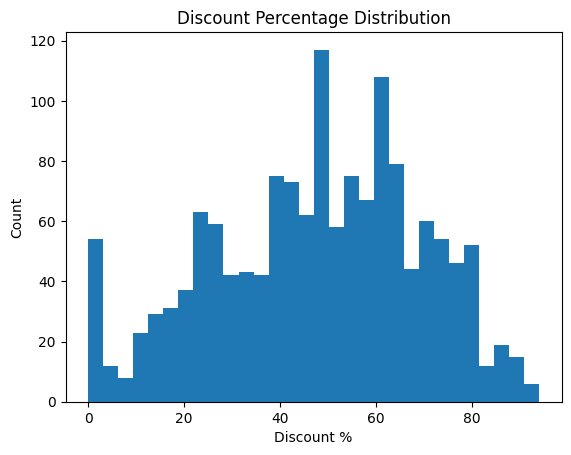

In [66]:
plt.hist(df["discount_percentage"], bins=30)
plt.title("Discount Percentage Distribution")
plt.xlabel("Discount %")
plt.ylabel("Count")
plt.show()

Shows:

* Heavy discounting trend

### **Price vs. Rating**



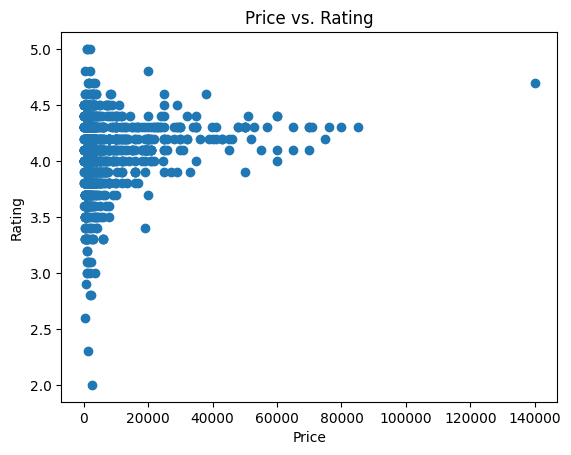

In [67]:
plt.scatter(df["actual_price"], df["rating"])
plt.title("Price vs. Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.show()

Shows:

* No strong relationship

### **Feature Engineering**



In [68]:
# Value Score
df["value_score"] = df["rating"] / df["discounted_price"]

# Best Value Products
df.sort_values("value_score", ascending=False)[
    ["product_name", "actual_price", "discounted_price", "rating", "value_score"]
].head(10)

,product_name,actual_price,discounted_price,rating,value_score
975,E-COSMOS 5V 1.2W Portable Flexible USB LED Lig...,39.0,39.00,3.8,0.097436
997,Inventis 5V 1.2W Portable Flexible USB LED Lig...,39.0,39.00,3.6,0.092308
645,GIZGA essentials Universal Silicone Keyboard P...,299.0,39.00,3.5,0.089744
616,Classmate Octane Neon- Blue Gel Pens(Pack of 5...,50.0,50.00,4.3,0.086000
178,FLiX (Beetel Flow USB to Micro USB PVC Data Sy...,199.0,57.89,4.0,0.069097
478,Flix Micro Usb Cable For Smartphone (Black),199.0,59.00,4.0,0.067797
727,Flix Micro Usb Cable For Smartphone (Black),199.0,59.00,4.0,0.067797
23,Flix Micro Usb Cable For Smartphone (Black),199.0,59.00,4.0,0.067797
44,FLiX (Beetel USB to Micro USB PVC Data Sync & ...,199.0,59.00,4.0,0.067797
710,E-COSMOS 5V 1.2W Portable Flexible USB LED Lig...,59.0,59.00,3.8,0.064407


Top value products combine high ratings with low prices, offering better customer-perceived value than expensive alternates.

### **Most Common Words in Reviews**



In [69]:
from collections import Counter

text = " ".join(df["review_content"].dropna())
words = text.lower().split()
common_words = Counter(words).most_common(20)
common_words

[('the', 12963),
 ('is', 9858),
 ('and', 9375),
 ('to', 7788),
 ('it', 6546),
 ('for', 6449),
 ('a', 6014),
 ('i', 5471),
 ('of', 4528),
 ('this', 4299),
 ('in', 3963),
 ('good', 3648),
 ('but', 3358),
 ('with', 3250),
 ('not', 3200),
 ('you', 2554),
 ('on', 2286),
 ('product', 2213),
 ('as', 2195),
 ('my', 2179)]

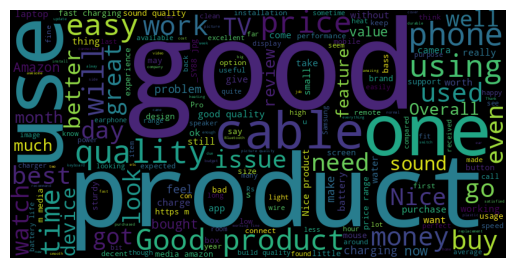

In [70]:
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

### **Category Visualization**



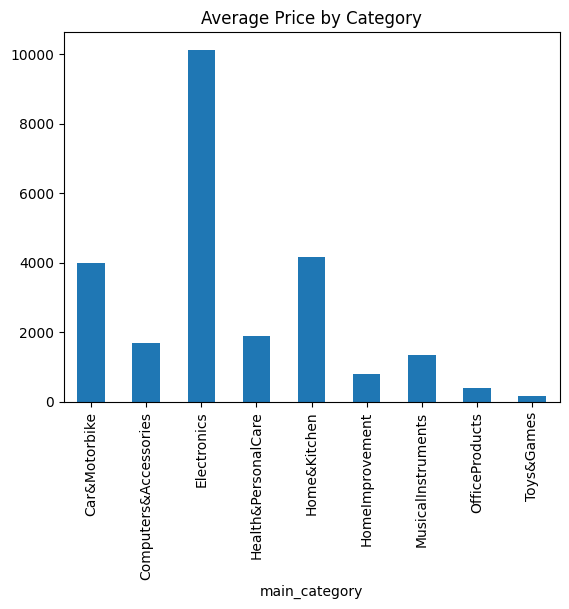

In [71]:
df.groupby("main_category")["actual_price"].mean().plot(kind="bar")
plt.title("Average Price by Category")
plt.show()

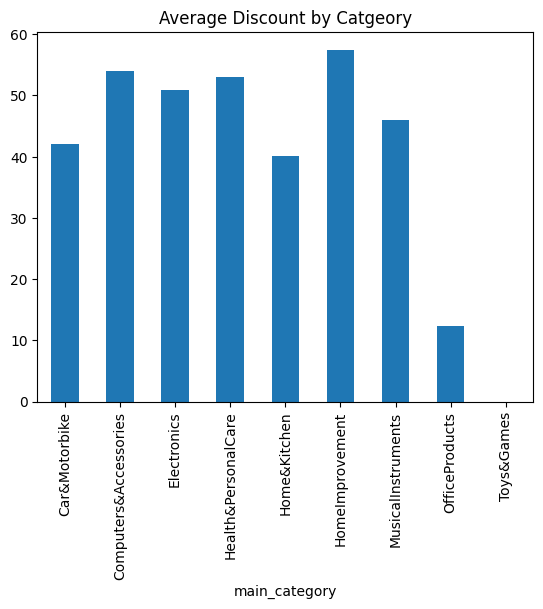

In [72]:
df.groupby("main_category")["discount_percentage"].mean().plot(kind="bar")
plt.title("Average Discount by Catgeory")
plt.show()